# EfficientNet-B0: Ordinal Loss + Class Balancing

Este notebook combina três técnicas poderosas:
- **Entropy filtering**: Remove amostras de alta entropia (ambíguas)
- **Ordinal loss**: Respeita a ordem natural dos graus ISUP (0 < 1 < 2 < 3 < 4 < 5)
- **Class balancing**: Usa WeightedRandomSampler para balancear classes desbalanceadas

## Problema de Desbalanceamento

No dataset:
- **ISUP 0-1**: ~55% das amostras (benigno/baixo grau)
- **ISUP 4-5**: ~22% das amostras (alto grau - crítico)

Sem balanceamento, o modelo tende a:
- Prever mais ISUP 0-1 (maioria)
- Ter baixa performance em ISUP 4-5 (crítico para diagnóstico)

## Solução: Weighted Sampling

Usando `WeightedRandomSampler`, cada classe tem chance proporcional de aparecer nos batches,
dando às classes minoritárias mais oportunidades de serem aprendidas.

In [2]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import os
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuração

In [3]:
# Parâmetros de treinamento
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # Codificação ordinal: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seeds para reprodutibilidade
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Caminhos de saída
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-weighted.pth'
log_path = 'logs/b0-entropy-ordinal-weighted.txt'

Using device: cuda


## Ordinal Loss Function

Regressão ordinal trata o problema como uma série de classificações binárias:
- Para o grau ISUP k, predizemos k labels binários: [1,1,...,1,0,0,...,0]
- Exemplo: ISUP 2 → [1, 1, 0, 0, 0] (grau > 0, grau > 1, mas não > 2, > 3, > 4)

In [4]:
class OrdinalRegressionLoss(nn.Module):
    """
    Loss ordinal para categorias ordenadas.
    
    Para cada amostra com grau k, criamos k labels binários:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    """
    def __init__(self):
        super(OrdinalRegressionLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - saídas brutas do modelo
            targets: (batch_size, num_classes) - targets com codificação ordinal
        """
        return self.bce(logits, targets)

def encode_ordinal_labels(labels, num_classes=5):
    """
    Converte labels categóricos para codificação ordinal.
    
    Args:
        labels: Tensor ou array de graus ISUP (0-5)
        num_classes: Número de thresholds (5 para ISUP 0-5)
    
    Returns:
        Labels com codificação ordinal: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Converte predições ordinais de volta para labels de classe.
    
    Args:
        logits: (batch_size, num_classes) - saídas brutas do modelo
    
    Returns:
        Graus ISUP preditos (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Inicializar função de loss
loss_function = OrdinalRegressionLoss()
print("Ordinal Regression Loss inicializada")

Ordinal Regression Loss inicializada


## Carregar Dados com Filtro de Entropia

In [5]:
# Carregar dados de treino originais
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Registros originais: {len(df_train_)}")

# Carregar amostras filtradas por entropia
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"Amostras de alta entropia para remover: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filtrar amostras de alta entropia
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Registros filtrados: {len(df_train_)}")

# Limpar nomes de colunas
df_train_.columns = df_train_.columns.str.strip()

# Dividir por fold (fold 3 para validação)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Carregar dados de teste
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove linhas do df onde a imagem não existe em images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTreino: {len(df_train)} amostras")
print(f"Validação: {len(df_val)} amostras")
print(f"Teste: {len(df_test)} amostras")

# Verificar distribuição de classes
print(f"\nDistribuição de classes no treino:")
class_counts = df_train['isup_grade'].value_counts().sort_index()
print(class_counts)
print(f"\nProporções (%):")
for grade, count in class_counts.items():
    pct = count / len(df_train) * 100
    print(f"  ISUP {grade}: {count:4d} amostras ({pct:5.2f}%)")

Registros originais: 9024
Amostras de alta entropia para remover: 903
Registros filtrados: 8844

Treino: 7073 amostras
Validação: 1767 amostras
Teste: 1590 amostras

Distribuição de classes no treino:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64

Proporções (%):
  ISUP 0: 1953 amostras (27.61%)
  ISUP 1: 1802 amostras (25.48%)
  ISUP 2:  899 amostras (12.71%)
  ISUP 3:  826 amostras (11.68%)
  ISUP 4:  832 amostras (11.76%)
  ISUP 5:  761 amostras (10.76%)


## Computar Pesos para Balanceamento de Classes

Calculamos pesos inversamente proporcionais à frequência das classes:
- Classes raras (ISUP 4-5): Pesos maiores → amostradas mais frequentemente
- Classes comuns (ISUP 0-1): Pesos menores → amostradas menos frequentemente

In [6]:
# Computar pesos de classe (frequência inversa)
train_labels = df_train['isup_grade'].values
classes = np.unique(train_labels)

# Usar sklearn para computar pesos balanceados
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)

print("\nPesos de classe (para sampling balanceado):")
print("="*60)
for cls, weight in zip(classes, class_weights):
    count = (train_labels == cls).sum()
    print(f"  ISUP {int(cls)}: peso={weight:.4f} (n={count})")
print("="*60)

# Criar pesos de amostra para WeightedRandomSampler
sample_weights = np.array([class_weights[int(label)] for label in train_labels])
sample_weights = torch.from_numpy(sample_weights).float()

print(f"\nTotal de amostras: {len(sample_weights)}")
print(f"Range de pesos: [{sample_weights.min():.4f}, {sample_weights.max():.4f}]")
print(f"\nCom esses pesos, classes minoritárias serão amostradas ~{sample_weights.max()/sample_weights.min():.1f}x mais")


Pesos de classe (para sampling balanceado):
  ISUP 0: peso=0.6036 (n=1953)
  ISUP 1: peso=0.6542 (n=1802)
  ISUP 2: peso=1.3113 (n=899)
  ISUP 3: peso=1.4272 (n=826)
  ISUP 4: peso=1.4169 (n=832)
  ISUP 5: peso=1.5491 (n=761)

Total de amostras: 7073
Range de pesos: [0.6036, 1.5491]

Com esses pesos, classes minoritárias serão amostradas ~2.6x mais


## Data Augmentation

In [7]:
# Augmentação para treino
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# Sem augmentação para validação/teste
val_transforms = None

## Criar Datasets e DataLoaders com Sampling Balanceado

In [8]:
# Criar datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Criar WEIGHTED sampler para treino (sampling balanceado)
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Permitir amostragem com reposição para balanceamento
)

print("\n" + "="*60)
print("CONFIGURAÇÃO DE SAMPLING")
print("="*60)
print("Treino: WeightedRandomSampler (BALANCEADO)")
print("Validação: RandomSampler (não balanceado)")
print("Teste: Sequential (sem shuffle)")
print("="*60 + "\n")

# Criar dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=weighted_sampler  # Usar sampler ponderado
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)  # Validação permanece aleatória
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Batches de treino: {len(train_loader)} (com sampling balanceado)")
print(f"Batches de validação: {len(valid_loader)}")
print(f"Batches de teste: {len(test_loader)}")


CONFIGURAÇÃO DE SAMPLING
Treino: WeightedRandomSampler (BALANCEADO)
Validação: RandomSampler (não balanceado)
Teste: Sequential (sem shuffle)

Batches de treino: 2358 (com sampling balanceado)
Batches de validação: 589
Batches de teste: 530


## Verificar Balanceamento (Opcional)

Vamos verificar se nosso weighted sampler está produzindo batches mais balanceados.

In [9]:
# Amostrar alguns batches para verificar distribuição
print("\nAmostrando 100 batches para verificar balanceamento...")
sampled_labels = []
for i, (_, targets, _) in enumerate(train_loader):
    if i >= 100:
        break
    # Converter targets ordinais de volta para labels de classe
    class_labels = targets.sum(dim=1).numpy()
    sampled_labels.extend(class_labels)

sampled_labels = np.array(sampled_labels)

print("\n" + "="*60)
print("COMPARAÇÃO: ORIGINAL vs AMOSTRADO")
print("="*60)
print(f"{'Classe':<10} {'Original %':<15} {'Amostrado %':<15} {'Diferença'}")
print("-"*60)

for cls in classes:
    original_pct = (train_labels == cls).sum() / len(train_labels) * 100
    sampled_pct = (sampled_labels == cls).sum() / len(sampled_labels) * 100
    diff = sampled_pct - original_pct
    print(f"ISUP {int(cls):<4} {original_pct:>6.2f}%{' '*8} {sampled_pct:>6.2f}%{' '*8} {diff:+.2f}%")

print("="*60)
print("✓ Classes minoritárias devem ter % MAIOR no sampling balanceado")
print("="*60 + "\n")


Amostrando 100 batches para verificar balanceamento...

COMPARAÇÃO: ORIGINAL vs AMOSTRADO
Classe     Original %      Amostrado %     Diferença
------------------------------------------------------------
ISUP 0     27.61%          17.67%         -9.95%
ISUP 1     25.48%          15.67%         -9.81%
ISUP 2     12.71%          15.67%         +2.96%
ISUP 3     11.68%          15.67%         +3.99%
ISUP 4     11.76%          17.67%         +5.90%
ISUP 5     10.76%          17.67%         +6.91%
✓ Classes minoritárias devem ter % MAIOR no sampling balanceado



## Setup do Modelo

In [10]:
# Carregar EfficientNet-B0 pré-treinado
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Modelo carregado em {device}")
print(f"Dimensões de saída: {output_classes} (thresholds ordinais)")
print(f"Taxa de dropout: {dropout_rate}")

Modelo carregado em cuda
Dimensões de saída: 5 (thresholds ordinais)
Taxa de dropout: 0.6


## Optimizer e Scheduler

In [10]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler com warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer e scheduler configurados")

Optimizer e scheduler configurados


## Funções de Treinamento e Validação

In [11]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Executa uma época de treinamento.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Treinando")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Já em formato ordinal do PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Rastrear loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Executa validação.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validando")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Já ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decodificar predições (soma de thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Converter targets ordinais de volta para labels de classe para métricas
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenar todas as predições e targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calcular métricas
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    # Métricas por classe
    per_class_f1 = f1_score(all_targets, all_preds, average=None, zero_division=0)
    per_class_recall = recall_score(all_targets, all_preds, average=None, zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision,
        'per_class_f1': per_class_f1,
        'per_class_recall': per_class_recall
    }

## Loop de Treinamento

In [12]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Histórico de treinamento
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nIniciando treinamento com Loss Ordinal + Balanceamento de Classes...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nÉpoca {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Treinar
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validar
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Atualizar scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Salvar histórico
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Imprimir métricas
    print(f"\nResultados:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1 (macro): {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Imprimir métricas por classe
    print("\n  F1 por classe:")
    for i, f1 in enumerate(metrics['per_class_f1']):
        print(f"    ISUP {i}: {f1:.4f}")
    
    # Log para arquivo
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Salvar melhor modelo
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Melhor modelo salvo! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  Sem melhoria por {epochs_without_improvement} época(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping na época {epoch}")
        print(f"Melhor época: {best_epoch} com Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Treinamento concluído!")
print(f"Melhor Kappa de validação: {best_kappa:.4f} na época {best_epoch}")
print("="*80)


Iniciando treinamento com Loss Ordinal + Balanceamento de Classes...


Época 1/50
--------------------------------------------------------------------------------


Validando: 100%|██████████| 589/589 [01:36<00:00,  6.11it/s]



Resultados:
  Train Loss: 0.41224
  Val Loss: 0.29230
  Val Accuracy: 56.93%
  Val Kappa: 0.7852
  Val F1 (macro): 0.5174
  Learning Rate: 0.0003000

  F1 por classe:
    ISUP 0: 0.7744
    ISUP 1: 0.5627
    ISUP 2: 0.3779
    ISUP 3: 0.3409
    ISUP 4: 0.4083
    ISUP 5: 0.6404

  ✓ Melhor modelo salvo! Kappa: 0.7852

Época 2/50
--------------------------------------------------------------------------------


Validando: 100%|██████████| 589/589 [01:37<00:00,  6.05it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Resultados:
  Train Loss: 0.35588
  Val Loss: 0.30748
  Val Accuracy: 52.07%
  Val Kappa: 0.7922
  Val F1 (macro): 0.4672
  Learning Rate: 0.0003003

  F1 por classe:
    ISUP 0: 0.8254
    ISUP 1: 0.4444
    ISUP 2: 0.3778
    ISUP 3: 0.2693
    ISUP 4: 0.2914
    ISUP 5: 0.5948

  ✓ Melhor modelo salvo! Kappa: 0.7922

Época 3/50
--------------------------------------------------------------------------------


...


Resultados:
  Train Loss: 0.15539
  Val Loss: 0.25345
  Val Accuracy: 67.01%
  Val Kappa: 0.8540
  Val F1 (macro): 0.6203
  Learning Rate: 0.0001836

  F1 por classe:
    ISUP 0: 0.8556
    ISUP 1: 0.7348
    ISUP 2: 0.4721
    ISUP 3: 0.4689
    ISUP 4: 0.5258
    ISUP 5: 0.6649

  Sem melhoria por 5 época(s)

Época 24/50
--------------------------------------------------------------------------------


Validando: 100%|██████████| 589/589 [01:33<00:00,  6.32it/s]



Resultados:
  Train Loss: 0.14693
  Val Loss: 0.25091
  Val Accuracy: 67.52%
  Val Kappa: 0.8594
  Val F1 (macro): 0.6312
  Learning Rate: 0.0001741

  F1 por classe:
    ISUP 0: 0.8713
    ISUP 1: 0.7136
    ISUP 2: 0.4933
    ISUP 3: 0.5280
    ISUP 4: 0.5053
    ISUP 5: 0.6761

  Sem melhoria por 6 época(s)

Época 25/50
--------------------------------------------------------------------------------


Validando: 100%|██████████| 589/589 [01:32<00:00,  6.34it/s]



Resultados:
  Train Loss: 0.14684
  Val Loss: 0.25188
  Val Accuracy: 67.52%
  Val Kappa: 0.8550
  Val F1 (macro): 0.6310
  Learning Rate: 0.0001646

  F1 por classe:
    ISUP 0: 0.8803
    ISUP 1: 0.6860
    ISUP 2: 0.4893
    ISUP 3: 0.4961
    ISUP 4: 0.5471
    ISUP 5: 0.6870

  Sem melhoria por 7 época(s)

Early stopping na época 25
Melhor época: 18 com Kappa: 0.8603

Treinamento concluído!
Melhor Kappa de validação: 0.8603 na época 18


## Plot do Histórico de Treinamento

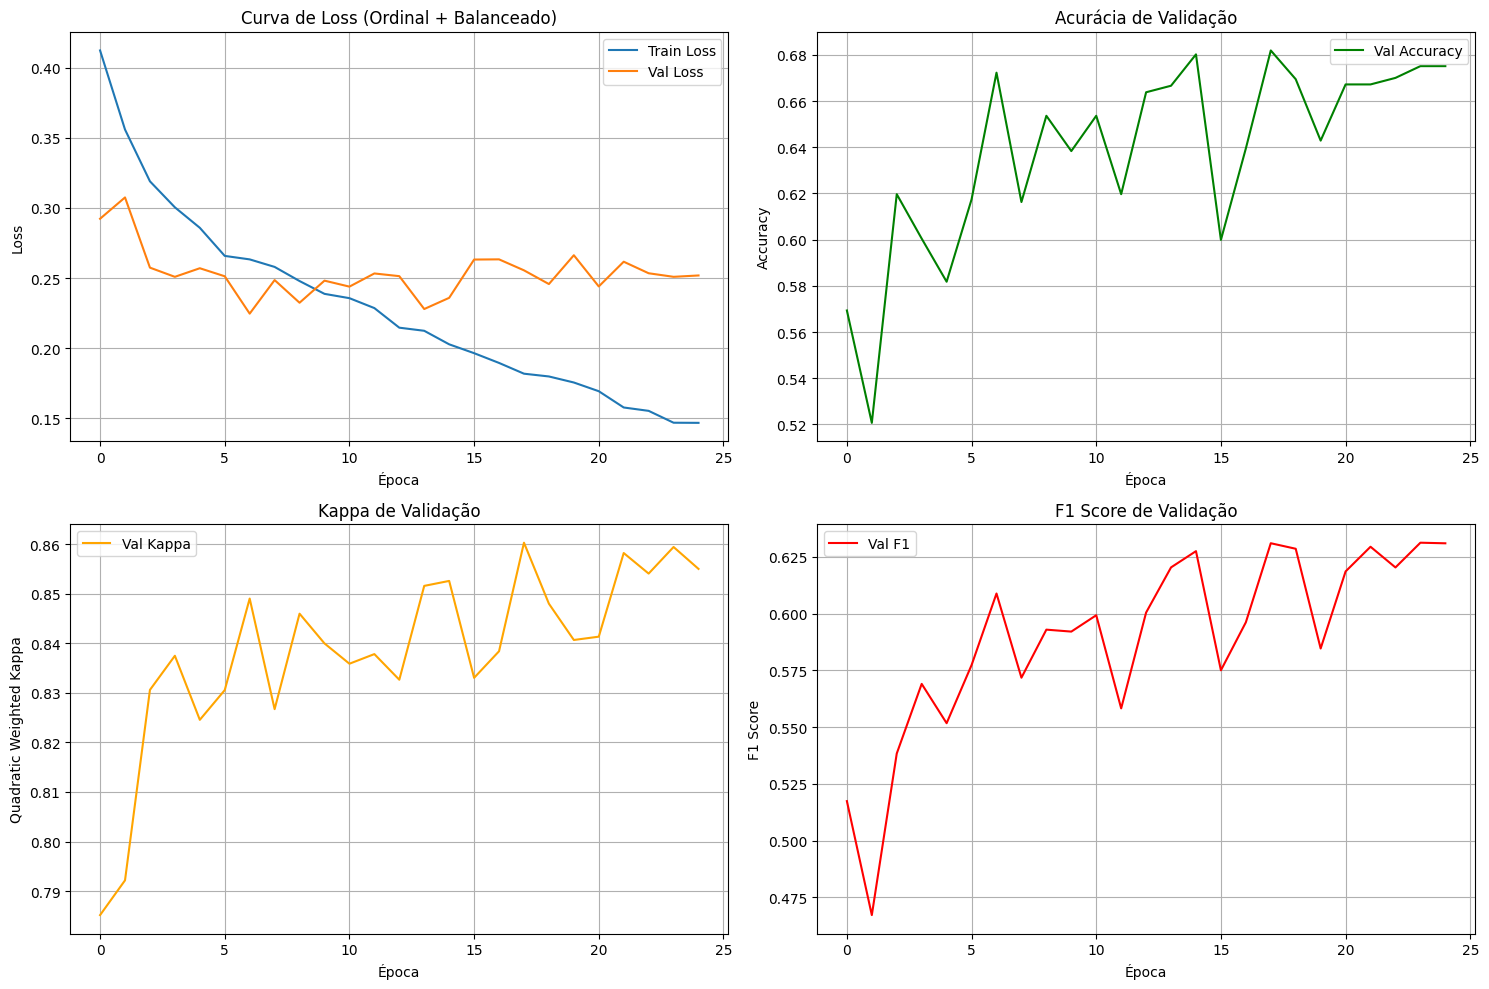

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Curva de Loss (Ordinal + Balanceado)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Acurácia de Validação')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Kappa de Validação')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('F1 Score de Validação')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-weighted-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Avaliação no Conjunto de Teste

Avaliando no conjunto de teste...



Testando: 100%|██████████| 530/530 [01:28<00:00,  6.02it/s]



RESULTADOS NO CONJUNTO DE TESTE
(Ordinal Loss + Balanceamento de Classes)
Accuracy: 67.30%
Quadratic Weighted Kappa: 0.8511
Macro F1 Score: 0.6262
Weighted F1 Score: 0.6699

Relatório de Classificação (verifique F1 das classes minoritárias):
              precision    recall  f1-score   support

      ISUP 0     0.7981    0.9470    0.8662       434
      ISUP 1     0.7967    0.5975    0.6829       400
      ISUP 2     0.4896    0.4700    0.4796       200
      ISUP 3     0.4676    0.5459    0.5037       185
      ISUP 4     0.5400    0.5775    0.5581       187
      ISUP 5     0.7006    0.6359    0.6667       184

    accuracy                         0.6730      1590
   macro avg     0.6321    0.6290    0.6262      1590
weighted avg     0.6788    0.6730    0.6699      1590


Matriz de Confusão:
[[411   9   2   6   6   0]
 [ 69 239  73  16   3   0]
 [  7  40  94  48   6   5]
 [ 10   5  19 101  35  15]
 [ 10   6   2  31 108  30]
 [  8   1   2  14  42 117]]


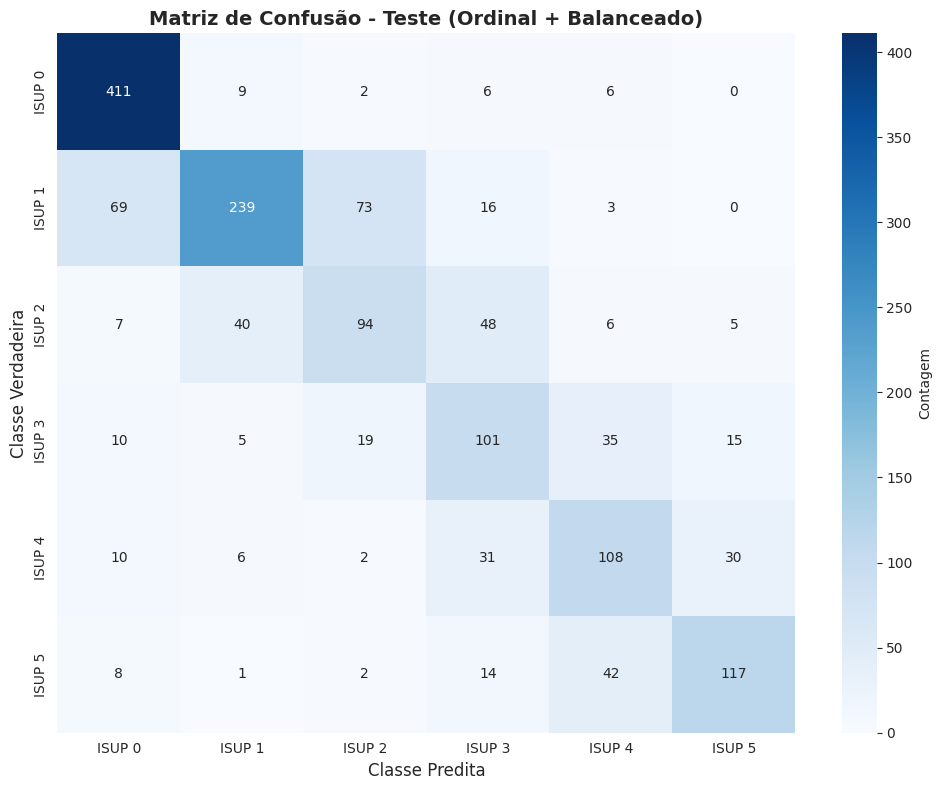


Resultados salvos em logs/b0-entropy-ordinal-weighted-test-results.txt


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar melhor modelo
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Avaliar no conjunto de teste
test_preds = []
test_targets = []

print("Avaliando no conjunto de teste...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testando"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decodificar predições
        predictions = decode_ordinal_predictions(logits)
        
        # Converter targets ordinais para labels de classe
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenar resultados
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calcular métricas
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1_macro = f1_score(test_targets, test_preds, average='macro', zero_division=0)
test_f1_weighted = f1_score(test_targets, test_preds, average='weighted', zero_division=0)

print("\n" + "="*80)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("(Ordinal Loss + Balanceamento de Classes)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1_macro:.4f}")
print(f"Weighted F1 Score: {test_f1_weighted:.4f}")
print("="*80)

# Relatório de classificação
print("\nRelatório de Classificação (verifique F1 das classes minoritárias):")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Matriz de confusão
cm = confusion_matrix(test_targets, test_preds)
print("\nMatriz de Confusão:")
print(cm)

# Plot da matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Contagem'}
)
plt.title('Matriz de Confusão - Teste (Ordinal + Balanceado)', fontsize=14, fontweight='bold')
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Classe Predita', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-weighted-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Salvar resultados de teste
with open('../logs/b0-entropy-ordinal-weighted-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0: Ordinal Loss + Balanceamento de Classes\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1_macro:.4f}\n")
    f.write(f"Test Weighted F1 Score: {test_f1_weighted:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nResultados salvos em logs/b0-entropy-ordinal-weighted-test-results.txt")

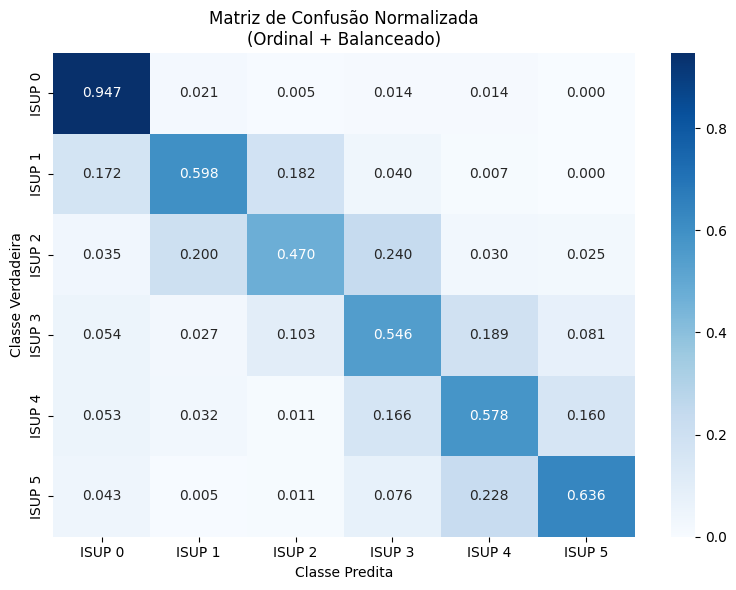

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusão normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels das classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matriz de Confusão Normalizada\n(Ordinal + Balanceado)")
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-weighted-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Resumo

Este notebook treinou EfficientNet-B0 combinando três técnicas:

### 1. **Filtro de Entropia**
Removeu os 20% das amostras mais difíceis/ambíguas para dados de treino mais limpos.

### 2. **Loss Ordinal**
Enforçou a ordenação natural dos graus ISUP através de codificação binária por threshold:
- ISUP 0: [0,0,0,0,0]
- ISUP 3: [1,1,1,0,0]
- ISUP 5: [1,1,1,1,1]

### 3. **Balanceamento de Classes (WeightedRandomSampler)**
- Computou pesos inversamente proporcionais à frequência das classes
- Classes raras (ISUP 4-5) são amostradas ~2-3x mais frequentemente
- Previne viés do modelo em favor das classes majoritárias

### Benefícios Esperados:

1. **Melhor performance em classes minoritárias**:
   - ISUP 4-5 devem ter F1/recall significativamente melhores
   - Crítico para detecção de câncer de alto grau

2. **Predições mais balanceadas**:
   - Menos viés para prever ISUP 0-1
   - Distribuição de predições mais uniforme

3. **Consistência ordinal mantida**:
   - Predições ainda respeitam ordenação natural
   - Erros "próximos" (ISUP 2→3) preferidos a "distantes" (ISUP 1→5)

### Comparar com:
- **Baseline ordinal** (sem balanceamento): Deve ter F1 macro menor, especialmente em ISUP 4-5
- **Ordinal + Focal Loss**: Abordagem diferente para o mesmo problema

### Métricas-chave para analisar:
- **Per-class F1**: Especialmente ISUP 4-5 (minoritárias)
- **Per-class Recall**: Sensibilidade para cada grau
- **Macro F1** vs **Weighted F1**: Macro dá peso igual a todas as classes
- **Matriz de confusão normalizada**: Mostra erros relativos dentro de cada classe